In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import starbars
import pandas as pd
import torch
from scipy.stats import ttest_ind, ttest_rel, ranksums
from scipy.ndimage import convolve1d
from torcheval.metrics.functional import r2_score

In [2]:
method_list = [
    "lrRNN",
    "lrRNN+ICA",
    "LINT",
    "bdRNN",
    "DisRNN-full",
    "DisRNN",
]
seed_list = np.arange(10)

In [3]:
df_data = pd.read_pickle("data/data.pkl")

W_true = df_data.at[0, "A"] @ df_data.at[0, "B"]
J_true = df_data.at[0, "B"] @ df_data.at[0, "A"]

/tmp/ipykernel_1464842/2891476545.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"results_{tag}/{method}_{seed}_group_aligned_z_pred_mean.pt")[


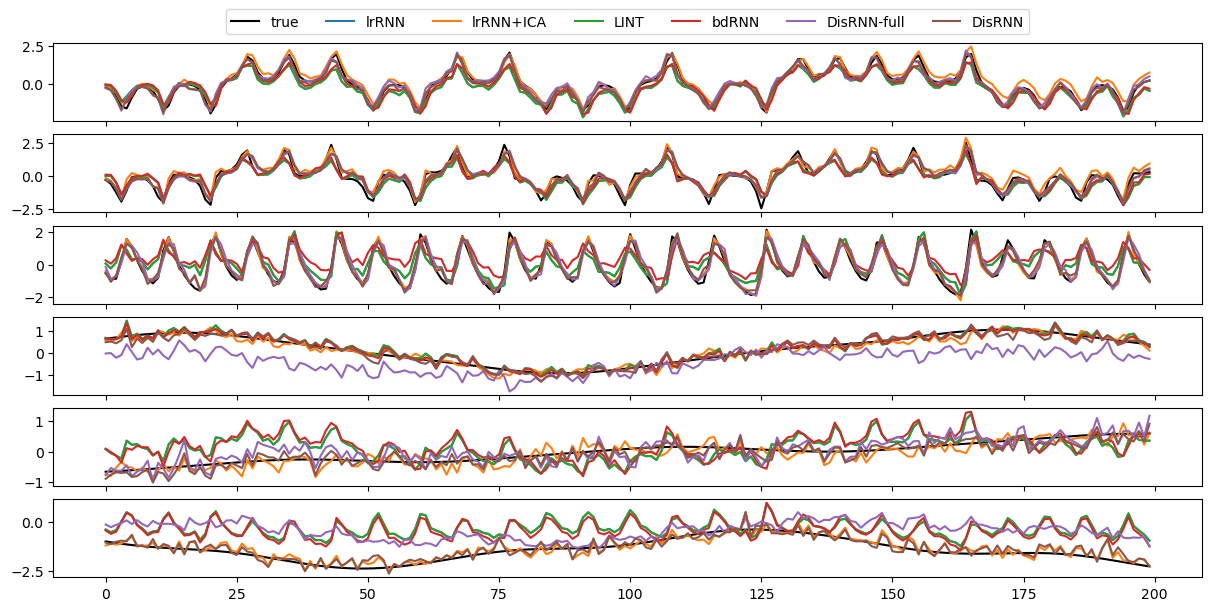

In [16]:
seed = 0

fig, axs = plt.subplots(6, 1, figsize=(12, 6), layout="constrained", sharex=True)
for component in range(6):
    ax = axs[component]
    ax.plot(df_data.at[0, "z"][1000:1200, component], "k", label="true")
    for method in method_list:
        ax.plot(
            torch.load(f"results_{tag}/{method}_{seed}_group_aligned_z_pred_mean.pt")[
                1000:1200, component
            ],
            label=method,
        )
axs[0].legend(ncol=7, bbox_to_anchor=(0.5, 1.02), loc="lower center")
fig.savefig("synthetic_rnn_latent.pdf", transparent=True)

/tmp/ipykernel_1389452/1171322352.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  A = torch.load(f"{results_file}/{method}_{seed}_A.pt")
/tmp/ipykernel_1389452/117132235

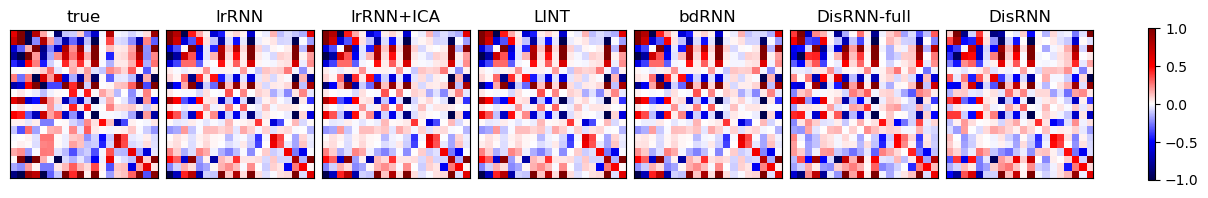

In [7]:
seed = 0

fig, axs = plt.subplots(1, 7, figsize=(12, 2), layout="constrained")
for method, ax in zip(["true"] + method_list, axs):
    if method == "true":
        W_hat = W_true
    else:
        A = torch.load(f"{results_file}/{method}_{seed}_A.pt")
        B = torch.load(f"{results_file}/{method}_{seed}_B.pt")
        W_hat = A @ B
    ax.matshow(
        W_hat.detach().numpy(),
        cmap="seismic",
        vmin=-1,
        vmax=1,
    )
    ax.set(xticks=[], yticks=[], title=method)

fig.colorbar(
    axs[0].get_children()[0],
    ax=axs,
    shrink=0.8,
)

fig.savefig("synthetic_rnn_connectivity.pdf", transparent=True)

/tmp/ipykernel_3388240/217468281.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  z_disrnn = torch.load(f"results_{tag}/{method}_1_group_aligned_z_pred_mean.pt")
/tmp/ip

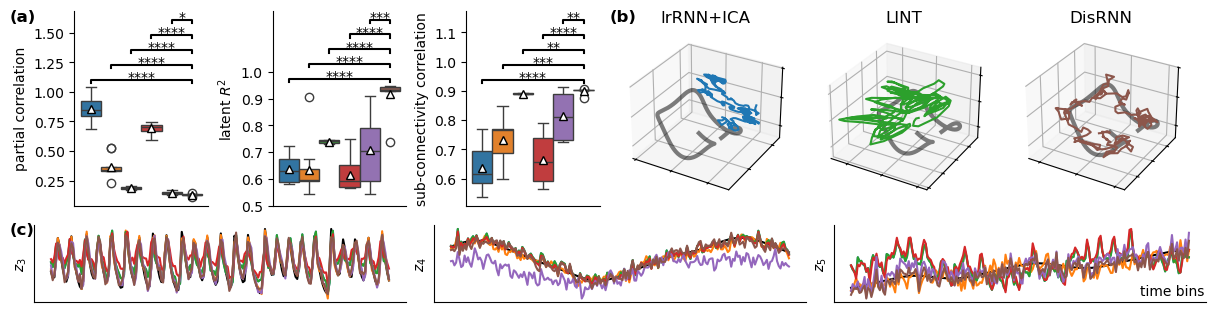

In [7]:
tag = "baseline"

fig = plt.figure(figsize=(12, 3), layout="constrained")
subfigs = fig.subfigures(2, 1, height_ratios=[5, 2])

subfig = subfigs[0]
subsubfigs = subfig.subfigures(1, 2)

axs = subsubfigs[0].subplots(1, 3)
for metric, ax in zip(
    ["partial correlation", "group latent $R^2$", "sub-connectivity correlation"], axs
):
    sns.boxplot(
        y=metric,
        hue="method",
        data=df_result,
        ax=ax,
        hue_order=method_list,
        # legend=False,
        showmeans=True,
        meanprops={"markerfacecolor": "white", "markeredgecolor": "black"},
    )

    pair_list = [
        ("DisRNN", "DisRNN-full"),
        ("DisRNN", "bdRNN"),
        ("DisRNN", "LINT"),
        ("DisRNN", "lrRNN+ICA"),
        ("DisRNN", "lrRNN"),
    ]
    annotations = []
    for pair in pair_list:
        if metric != "connectivity error":
            pvalue = ttest_rel(
                df_result[df_result["method"] == pair[0]][metric],
                df_result[df_result["method"] == pair[1]][metric],
            ).pvalue
        else:
            pvalue = ttest_ind(
                df_result[df_result["method"] == pair[0]][metric],
                df_result[df_result["method"] == pair[1]][metric],
                equal_var=False,
            ).pvalue
        annotations.append(
            (
                (pair[0], ""),
                (pair[1], ""),
                pvalue,
            )
        )
    starbars.draw_annotation(annotations, ax=ax, bar_gap=-0.01, h_gap=0)
    ax.set(xticks=[])
    ax.legend_.remove()
    sns.despine(ax=ax, top=True, right=True)

axs[1].set(yticks=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0], ylabel="latent $R^2$")

for i, method, c in zip([1, 2, 3], ["lrRNN+ICA", "LINT", "DisRNN"], ["C0", "C2", "C5"]):
    ax = subsubfigs[1].add_subplot(1, 3, i, projection="3d")
    ax.plot(
        df_data.at[0, "z"][1000:1200, 3],
        df_data.at[0, "z"][1000:1200, 4],
        df_data.at[0, "z"][1000:1200, 5],
        c="k",
        alpha=0.5,
        lw=3,
    )
    z_disrnn = torch.load(f"results_{tag}/{method}_1_group_aligned_z_pred_mean.pt")
    z_disrnn = convolve1d(z_disrnn, np.array([0.1, 0.2, 0.4, 0.2, 0.1]), axis=0)
    ax.plot(
        z_disrnn[1000:1200, 3],
        z_disrnn[1000:1200, 4],
        z_disrnn[1000:1200, 5],
        c=c,
    )
    ax.set(xticklabels=[], yticklabels=[], zticklabels=[], title=method)

axs = subfigs[1].subplots(1, 3, sharex=True)

seed = 0
for component, ax in zip([2, 3, 4], axs):
    ax.plot(df_data.at[0, "z"][1000:1200, component], "k", label="true")
    for method_idx, method in enumerate(method_list):
        ax.plot(
            torch.load(f"results_{tag}/{method}_{seed}_group_aligned_z_pred_mean.pt")[
                1000:1200, component
            ],
            label=method,
        )
    ax.set(ylabel=f"$z_{component+1}$", xticks=[], yticks=[])
    sns.despine(ax=ax, top=True, right=True)
ax.text(170, -0.9, "time bins")

# axs[2].legend()

fig.text(0, 0.99, "(a)", ha="left", va="top", weight="bold", fontsize="large")
fig.text(0.5, 0.99, "(b)", ha="left", va="top", weight="bold", fontsize="large")
fig.text(0, 0.28, "(c)", ha="left", va="top", weight="bold", fontsize="large")
# fig.savefig("synthetic_rnn.pdf", transparent=True, bbox_inches="tight")
fig.savefig("synthetic_rnn_3D.pdf", transparent=True, bbox_inches="tight")

/tmp/ipykernel_1371680/2665477059.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  A = torch.load(f"{results_file}/{method}_{seed}_A.pt")
/tmp/ipykernel_1371680/266547705

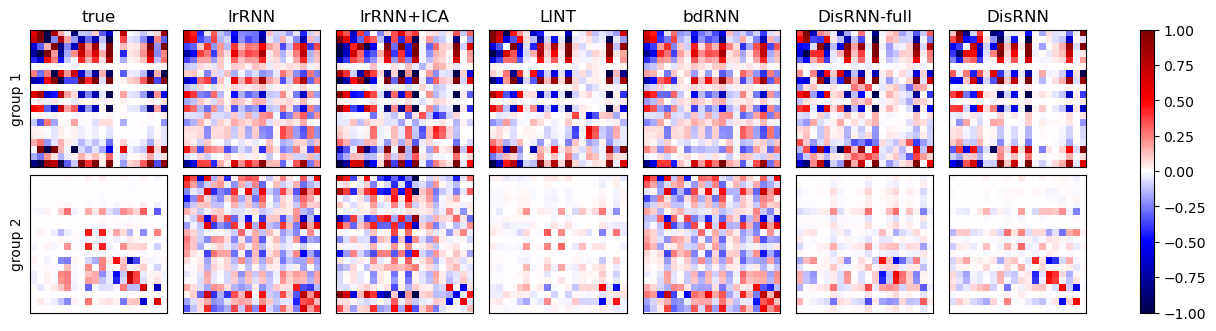

In [15]:
seed = 0

fig, axs = plt.subplots(2, 7, figsize=(12, 3.2), layout="constrained")
for method, ax in zip(["true"] + method_list, axs.T):
    if method == "true":
        A, B = df_data.at[0, "A"], df_data.at[0, "B"]
    else:
        A = torch.load(f"{results_file}/{method}_{seed}_A.pt")
        B = torch.load(f"{results_file}/{method}_{seed}_B.pt")
    W1 = (A[:, :3] @ B[:3, :]).detach().numpy()
    W2 = (A[:, 3:] @ B[3:, :]).detach().numpy()
    if method in ["lrRNN", "lrRNN+ICA", "bdRNN", "DisRNN-full", "DisRNN"]:
        W1, W2 = W2, W1
    ax[0].matshow(
        W1,
        cmap="seismic",
        vmin=-1,
        vmax=1,
    )
    ax[1].matshow(
        W2,
        cmap="seismic",
        vmin=-1,
        vmax=1,
    )
    ax[0].set(xticks=[], yticks=[], title=method)
    ax[1].set(xticks=[], yticks=[])
fig.colorbar(
    axs[0, 0].get_children()[0],
    ax=axs,
)
axs[0, 0].set(ylabel="group 1")
axs[1, 0].set(ylabel="group 2")

fig.savefig("synthetic_rnn_sub-connectivity.pdf", transparent=True)

In [13]:
df_perm_list = []
for method in ["lrRNN", "lrRNN+ICA", "LINT", "DisRNN-full"]:
    for seed in seed_list:
        df_temp = pd.DataFrame(
            {
                "latent $R^2$": torch.load(
                    f"{results_file}/{method}_{seed}_all_r2_scores.pt"
                )
            }
        )
        df_temp["method"] = method
        df_temp["seed"] = seed
        df_perm_list.append(df_temp)
df_perm = pd.concat(df_perm_list, ignore_index=True)

/tmp/ipykernel_1371680/3776058026.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  "latent $R^2$": torch.load(
/tmp/ipykernel_1371680/3776058026.py:6: FutureWarning: You 

/tmp/ipykernel_1371680/1724676592.py:10: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  complexity[i, j] = np.math.factorial(k) // (
/tmp/ipykernel_1371680/1724676592.py:11: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  np.math.factorial(g) * (np.math.factorial(h)) ** g


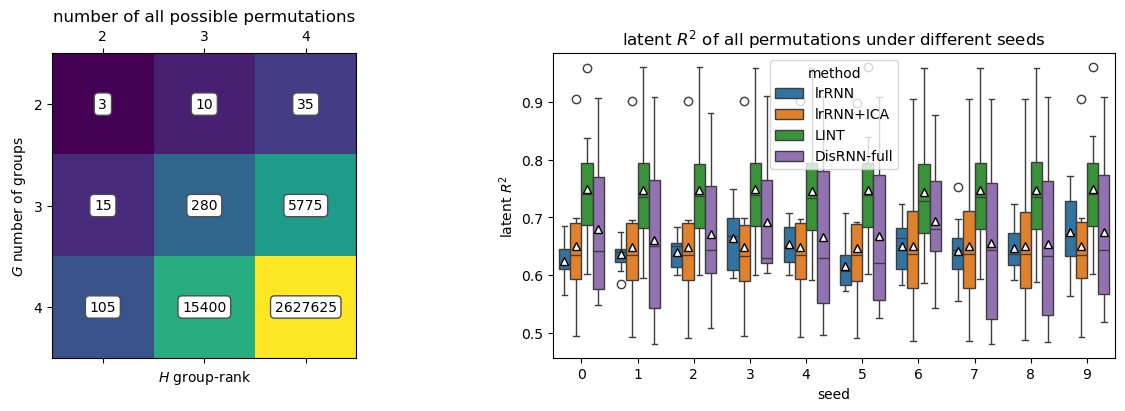

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
ax = axs[0]

g_list = np.arange(2, 5)
h_list = np.arange(2, 5)
complexity = np.zeros((len(g_list), len(h_list)))
for i, g in enumerate(g_list):
    for j, h in enumerate(h_list):
        k = h * g
        complexity[i, j] = np.math.factorial(k) // (
            np.math.factorial(g) * (np.math.factorial(h)) ** g
        )
ax.matshow(np.log10(complexity), cmap="viridis")
for i in range(len(g_list)):
    for j in range(len(h_list)):
        ax.text(
            j,
            i,
            f"{complexity[i, j]:.0f}",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.3"),
        )
ax.set(
    xticks=np.arange(len(h_list)),
    xticklabels=h_list,
    yticks=np.arange(len(g_list)),
    yticklabels=g_list,
    xlabel="$H$ group-rank",
    ylabel="$G$ number of groups",
    title="number of all possible permutations",
)

ax = axs[1]
sns.boxplot(
    y="latent $R^2$",
    x="seed",
    hue="method",
    data=df_perm,
    ax=ax,
    hue_order=["lrRNN", "lrRNN+ICA", "LINT", "DisRNN-full"],
    palette=["C0", "C1", "C2", "C4"],
    showmeans=True,
    meanprops={"markerfacecolor": "white", "markeredgecolor": "black"},
)
ax.set(
    title="latent $R^2$ of all permutations under different seeds",
)
fig.savefig("synthetic_rnn_permutations.pdf", transparent=True)